### OBS: Só roda com Python 3.12


# 🧑‍🏫 Aula 8 — Aprendizado por Reforço (Reinforcement Learning)

**UC:** Machine Learning | **Data:** 03/06/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Nas aulas anteriores trabalhamos com **aprendizado supervisionado** (com rótulos), **não supervisionado** (sem rótulos), **redes neurais**, **NLP** e **LLMs com RAG**. Hoje vamos abordar um paradigma fundamentalmente diferente: o **Aprendizado por Reforço (RL)**.

No RL não temos um dataset pronto com respostas certas. Em vez disso, um **agente** interage com um **ambiente**, executa **ações**, recebe **recompensas** e aprende — **por tentativa e erro** — qual é a **política ótima** (o que fazer em cada situação) para maximizar a recompensa acumulada ao longo do tempo.

### O que você vai aprender hoje:

1. 🎮 **Fundamentos de RL** — Agente, ambiente, estado, ação, recompensa, política, Q-table
2. 📐 **Equação de Bellman** — A "fórmula mágica" que sustenta o Q-Learning
3. 🚖 **Gymnasium Taxi** — Treinar um táxi virtual a buscar e entregar passageiros
4. 🧮 **Q-Learning** — Algoritmo *off-policy* clássico
5. 🔄 **SARSA** — Algoritmo *on-policy* (variante do Q-Learning)
6. 🎲 **ε-greedy** — Equilíbrio entre **exploração** e **explotação**
7. 🏭 **Case Têxtil** — Otimização do atendimento de um operador a múltiplos teares (ambiente próprio)
8. 📊 **MLflow Tracking** — Registrar experimentos e curvas de aprendizado

### Recapitulando a trilha:

| Aula | Paradigma | Como o modelo aprende? |
|---|---|---|
| 1–3 | Supervisionado | A partir de pares (X, y) com rótulos |
| 4 | Não supervisionado | A partir da estrutura/distribuição dos dados |
| 5 | Redes Neurais | Backpropagation + gradiente descendente |
| 6 | NLP | Embeddings + LSTM treinados com supervisão |
| 7 | LLMs + RAG | Modelo pré-treinado + recuperação de contexto |
| **8** | **Reinforcement Learning** | **Tentativa e erro com recompensa** |

> 📦 **Ambientes desta aula:**
> - **Gymnasium Taxi-v3** — clássico de RL (problema didático)
> - **TextilOperatorEnv** — ambiente próprio modelando o atendimento de um operador a 3 teares


## 1️⃣ Configuração do Ambiente e Instalação de Bibliotecas

Nesta aula a grande novidade é o **`gymnasium`** (sucessor do antigo `gym` da OpenAI) — uma biblioteca padrão para criar/usar ambientes de Reinforcement Learning.

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `gymnasium` | Ambientes padronizados de RL (Taxi, CartPole, etc.) | ✅ **Novo** |
| `numpy` | Q-table como array NumPy | — |
| `matplotlib` | Curvas de aprendizado | — |
| `pandas` | Tabela de resultados | — |
| `mlflow` | Tracking de experimentos | — |
| `pygame` | Renderização gráfica dos ambientes (Taxi) | ✅ **Novo** |
| `imageio` | Salvar animações dos episódios (GIF) | ✅ **Novo** |


In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# Gymnasium é a biblioteca da Farama Foundation (sucessora do
# OpenAI Gym) que fornece ambientes padronizados de RL.
#
# Extras desta versão visual:
#   - gymnasium[toy-text] + pygame → renderização gráfica do Taxi
#   - imageio                      → exportar episódios como GIF

%pip install -q "gymnasium[toy-text]" pygame imageio mlflow matplotlib pandas numpy joblib


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

# --- Gymnasium: Ambientes de RL ---
import gymnasium as gym

# --- Numérico / Dados ---
import numpy as np
import pandas as pd

# --- Visualização ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import animation
from IPython.display import HTML

# --- Paralelismo (treinar nos múltiplos cores) ---
from joblib import Parallel, delayed
import multiprocessing as mp

# --- Tracking de experimentos ---
import mlflow

# --- Persistência de modelos (Q-tables) ---
import joblib
import json
from pathlib import Path
import time

# --- Configuração visual ---
plt.style.use("seaborn-v0_8-whitegrid")

# --- Reprodutibilidade ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"   🎮 gymnasium: {gym.__version__}")
print(f"   🔢 numpy:     {np.__version__}")
print(f"   📊 mlflow:    {mlflow.__version__}")
print(f"   🧩 cores disponíveis (os.cpu_count): {os.cpu_count()}")


✅ Todas as bibliotecas foram importadas com sucesso!
   🎮 gymnasium: 1.3.0
   🔢 numpy:     2.4.6
   📊 mlflow:    3.13.0
   🧩 cores disponíveis (os.cpu_count): 16


### 🎥 Helpers de Visualização (animações dos ambientes)

Para *ver* os agentes atuando, usamos o modo `render_mode="rgb_array"` do Gymnasium: a cada passo o ambiente devolve uma **imagem** (array RGB). Juntamos esses quadros numa **animação** que toca dentro do próprio notebook (e pode ser salva como GIF).

| Função | O que faz |
|---|---|
| `record_frames(env, policy_fn, ...)` | Roda 1 episódio e coleta os quadros (imagens) |
| `frames_to_animation(frames)` | Transforma a lista de quadros num vídeo embutido (HTML) |
| `save_gif(frames, path)` | Salva a animação como `.gif` (opcional) |

> 💡 A animação fica **gravada no `.ipynb`** — funciona mesmo sem interface gráfica (modo *headless*). Mais adiante há também uma célula **opcional** que abre a janela nativa do Gymnasium (`render_mode="human"`) quando você roda localmente.


In [3]:
# ============================================================
# HELPERS DE ANIMAÇÃO (reutilizados por Taxi e Têxtil)
# ============================================================
# Estratégia: coletar uma lista de quadros RGB (numpy arrays) e
# montá-los numa animação matplotlib que toca embutida na célula.

def record_frames(env, policy_fn, max_steps=200, seed=None):
    """Roda 1 episódio seguindo policy_fn(state) e devolve (frames, info).

    - env precisa ter sido criado com render_mode="rgb_array".
    - policy_fn recebe o estado e devolve a ação (ex.: lambda s: argmax(Q[s])).
    """
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0
    steps = 0
    for _ in range(max_steps):
        action = policy_fn(state)
        state, reward, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    info = {"total_reward": total_reward, "steps": steps,
            "terminated": bool(terminated)}
    return frames, info


def frames_to_animation(frames, interval=300, title=None, figsize=(5, 5)):
    """Converte uma lista de imagens RGB numa animação HTML embutida."""
    plt.ioff()                       # evita figura estática duplicada
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    if title:
        ax.set_title(title)
    img = ax.imshow(frames[0])

    def update(i):
        img.set_data(frames[i])
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=interval, blit=True
    )
    plt.close(fig)
    plt.ion()
    return HTML(anim.to_jshtml())


def save_gif(frames, path, fps=4):
    """Salva os quadros como GIF (opcional). Requer imageio."""
    import imageio.v2 as imageio
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    imageio.mimsave(path, frames, fps=fps)
    print(f"   💾 GIF salvo em: {path}")

print("✅ Helpers de animação prontos: record_frames(), frames_to_animation(), save_gif()")


✅ Helpers de animação prontos: record_frames(), frames_to_animation(), save_gif()


## 2️⃣ Fundamentos de Reinforcement Learning

### Os 5 elementos do RL

```
                ┌─────────────┐
                │   AGENTE    │  ← quem aprende (o nosso "modelo")
                └──────┬──────┘
                       │ ação a_t
                       ▼
                ┌─────────────┐
                │  AMBIENTE   │  ← o "mundo" onde o agente atua
                └──────┬──────┘
                       │ estado s_{t+1} + recompensa r_{t+1}
                       ▼
                ┌─────────────┐
                │   AGENTE    │  ← observa e decide a próxima ação
                └─────────────┘
```

| Elemento | Símbolo | O que é |
|---|---|---|
| **Agente** | — | Quem toma decisões e aprende |
| **Ambiente** | — | Onde o agente atua (jogo, fábrica, robô…) |
| **Estado** | $s_t$ | Situação do ambiente no instante $t$ |
| **Ação** | $a_t$ | O que o agente faz no instante $t$ |
| **Recompensa** | $r_{t+1}$ | Feedback numérico após executar $a_t$ |
| **Política** | $\pi(s)$ | Estratégia: que ação tomar em cada estado |

### Função de Valor Q(s, a)

Em vez de prever um rótulo, queremos estimar **quanto vale executar a ação $a$ no estado $s$**. Essa função é chamada de **Q-value**:

$$Q(s, a) = \text{recompensa esperada se eu executar } a \text{ em } s \text{ e depois agir de forma ótima}$$

A **Q-table** é simplesmente uma matriz $|S| \times |A|$ com esses valores. Para Taxi-v3: 500 estados × 6 ações = 3000 entradas.

### Equação de Bellman (a "fórmula mágica")

$$Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \big]$$

Em palavras: o novo Q(s, a) é o antigo **mais um pequeno passo** na direção do **erro de previsão**:

| Símbolo | Nome | Valor típico | O que faz |
|---|---|---|---|
| $\alpha$ | Taxa de aprendizado | 0.1 | Quão rápido aprendemos (passo) |
| $\gamma$ | Fator de desconto | 0.99 | Quanto valorizamos recompensas futuras |
| $r$ | Recompensa imediata | varia | O que ganhei agora |
| $\max_{a'} Q(s', a')$ | Melhor valor futuro | — | Estimativa do que vale o estado seguinte |

### Exploração vs Explotação (ε-greedy)

Se o agente sempre escolhesse a melhor ação conhecida (**explotação**), nunca descobriria estratégias melhores. Se sempre escolhesse aleatório (**exploração**), nunca usaria o que aprendeu. A solução clássica é **ε-greedy**:

```
Sortear um número aleatório u em [0, 1]
Se u < ε  →  ação aleatória  (EXPLORA)
Se u ≥ ε  →  argmax Q(s, a)  (EXPLOTA)
```

E fazemos $\varepsilon$ **decair** ao longo do treinamento: começa explorando muito (ε=1.0) e termina explorando pouco (ε=0.01).


## 3️⃣ Conhecendo o Ambiente Gymnasium Taxi-v3

O **Taxi-v3** é o "Hello World" do RL. O agente é um táxi numa grade 5×5 que precisa:

1. Ir até a posição do passageiro (R, G, Y, B)
2. Embarcar o passageiro (ação `pickup`)
3. Levá-lo até o destino
4. Desembarcar (ação `dropoff`)

### Espaço de Estados e Ações

| | Tamanho | Descrição |
|---|---|---|
| **Estados** | 500 | 25 posições × 5 locais do passageiro × 4 destinos |
| **Ações** | 6 | 0=Sul, 1=Norte, 2=Leste, 3=Oeste, 4=Pickup, 5=Dropoff |

### Função de Recompensa

| Evento | Recompensa |
|---|---|
| Cada passo | −1 (incentiva caminhos curtos) |
| Pickup/Dropoff inválido | −10 |
| Dropoff bem-sucedido | +20 |


In [6]:
# ============================================================
# 3.1 — CRIAR E EXPLORAR O AMBIENTE TAXI
# ============================================================
# render_mode="ansi" devolve a representação textual do tabuleiro
# (string colorida com códigos ANSI). É leve e funciona em notebooks.

env_taxi = gym.make("Taxi-v4", render_mode="ansi")

print(f"🚖 Ambiente Taxi-v4 criado!")
print(f"   📦 Espaço de estados: {env_taxi.observation_space}")
print(f"   🎮 Espaço de ações:   {env_taxi.action_space}")
print(f"   🔢 |S| = {env_taxi.observation_space.n}  (500 = 25 pos × 5 passageiros × 4 destinos)")
print(f"   🔢 |A| = {env_taxi.action_space.n}    (Sul, Norte, Leste, Oeste, Pickup, Dropoff)")

# Reset: começa um novo episódio. Retorna estado inicial e um dict info.
obs, info = env_taxi.reset(seed=RANDOM_STATE)
print(f"\n🔄 Estado inicial (após reset): {obs}")
print(f"\n🗺️ Visualização do tabuleiro:")
print(env_taxi.render())


🚖 Ambiente Taxi-v4 criado!
   📦 Espaço de estados: Discrete(500)
   🎮 Espaço de ações:   Discrete(6)
   🔢 |S| = 500  (500 = 25 pos × 5 passageiros × 4 destinos)
   🔢 |A| = 6    (Sul, Norte, Leste, Oeste, Pickup, Dropoff)

🔄 Estado inicial (após reset): 386

🗺️ Visualização do tabuleiro:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [7]:
# ============================================================
# 3.2 — EXECUTAR UM AGENTE ALEATÓRIO (BASELINE)
# ============================================================
# Antes de treinar nada, vamos ver como se sai um agente que
# escolhe ações aleatórias. Isso vira nossa LINHA DE BASE.
# Depois compararemos com o agente treinado por Q-Learning.

def run_random_agent(env, n_episodes=50, max_steps=200, seed=RANDOM_STATE):
    """Executa um agente que escolhe ações aleatoriamente."""
    rng = np.random.default_rng(seed)
    rewards_per_episode = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
        total_reward = 0
        for step in range(max_steps):
            action = env.action_space.sample()              # ← ação aleatória
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        rewards_per_episode.append(total_reward)
    return np.array(rewards_per_episode)

random_rewards = run_random_agent(env_taxi, n_episodes=50)
print(f"🎲 Agente Aleatório (50 episódios):")
print(f"   Recompensa média:  {random_rewards.mean():.2f}")
print(f"   Recompensa máxima: {random_rewards.max():.0f}")
print(f"   Recompensa mínima: {random_rewards.min():.0f}")
print(f"\n💡 Note que a média é bem negativa — o agente quase nunca")
print(f"   completa a tarefa por acaso. Vamos treinar e comparar!")


🎲 Agente Aleatório (50 episódios):
   Recompensa média:  -780.26
   Recompensa máxima: -623
   Recompensa mínima: -938

💡 Note que a média é bem negativa — o agente quase nunca
   completa a tarefa por acaso. Vamos treinar e comparar!


## 4️⃣ Q-Learning — Algoritmo *Off-Policy*

### Pseudo-código

```
Inicialize Q(s, a) = 0 para todo (s, a)
Para cada episódio:
    s ← reset()
    enquanto não terminou:
        # ε-greedy: escolhe ação para EXECUTAR
        com probabilidade ε:  a ← ação aleatória
        senão:                a ← argmax Q(s, ·)

        s', r ← step(a)

        # Atualização de Bellman (USA O MAX FUTURO):
        Q(s, a) ← Q(s, a) + α [ r + γ · max_{a'} Q(s', a') − Q(s, a) ]

        s ← s'
    decai ε
```

### Por que "off-policy"?

Porque a **política que o agente segue** (ε-greedy, com algum aleatório) é **diferente** da **política usada na atualização** (sempre o `max`, totalmente gulosa). O agente "estuda" a política ótima enquanto se comporta de forma exploratória.


In [8]:
# ============================================================
# 4.1 — IMPLEMENTAÇÃO DO Q-LEARNING
# ============================================================
# Implementação didática: cada linha foi escolhida para ficar
# o mais legível possível. Em produção usaríamos bibliotecas
# como Stable-Baselines3, mas aqui o objetivo é ENTENDER.

def train_q_learning(
    env,
    n_episodes=5000,
    max_steps=200,
    alpha=0.1,            # taxa de aprendizado (passo da atualização)
    gamma=0.99,           # fator de desconto (importância do futuro)
    epsilon_start=1.0,    # exploração inicial (100% aleatório)
    epsilon_min=0.01,     # exploração mínima
    epsilon_decay=0.999,  # decaimento multiplicativo por episódio
    seed=RANDOM_STATE,
    verbose=True,
):
    """Treina um agente com Q-Learning tabular num ambiente discreto."""
    n_states  = env.observation_space.n
    n_actions = env.action_space.n

    # Q-table: matriz (n_states x n_actions) inicializada com zeros.
    Q = np.zeros((n_states, n_actions))

    rng = np.random.default_rng(seed)
    epsilon = epsilon_start

    rewards_history = []   # recompensa total por episódio
    epsilon_history = []   # epsilon ao longo do treino

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
        total_reward = 0

        for step in range(max_steps):
            # --- Política ε-greedy: decide a ação ---
            if rng.random() < epsilon:
                action = env.action_space.sample()       # EXPLORA
            else:
                action = int(np.argmax(Q[state]))         # EXPLOTA

            # --- Executa a ação no ambiente ---
            next_state, reward, terminated, truncated, _ = env.step(action)

            # --- Atualização de Bellman (Q-Learning: usa MAX futuro) ---
            best_next = np.max(Q[next_state])
            td_target = reward + gamma * best_next * (not terminated)
            td_error  = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

            if terminated or truncated:
                break

        rewards_history.append(total_reward)
        epsilon_history.append(epsilon)
        # Decaimento do epsilon (cada vez explora menos)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if verbose and (ep + 1) % 1000 == 0:
            mean100 = np.mean(rewards_history[-100:])
            print(f"   Ep {ep+1:>5d}/{n_episodes} | ε={epsilon:.3f} | recompensa média (100 últimos) = {mean100:7.2f}")

    return Q, np.array(rewards_history), np.array(epsilon_history)

print("✅ Função train_q_learning() definida.")


✅ Função train_q_learning() definida.


In [9]:
# ============================================================
# 4.2 — TREINAR Q-LEARNING NO TAXI-V3
# ============================================================
# 5000 episódios é um bom compromisso para Taxi-v3: o agente
# converge para uma política ótima e o treino dura ~30s em CPU.

print("🧠 Treinando Q-Learning no Taxi-v3 (5000 episódios)...")
t0 = time.time()
Q_qlearn, rewards_qlearn, eps_qlearn = train_q_learning(
    env_taxi,
    n_episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.999,
)
elapsed_qlearn = time.time() - t0

print(f"\n✅ Treinamento concluído em {elapsed_qlearn:.1f}s")
print(f"   📈 Recompensa média (últimos 500 ep): {rewards_qlearn[-500:].mean():.2f}")
print(f"   🎯 Recompensa do agente aleatório:    {random_rewards.mean():.2f}")
print(f"   🚀 Melhoria: {rewards_qlearn[-500:].mean() - random_rewards.mean():.1f} pontos!")


🧠 Treinando Q-Learning no Taxi-v3 (5000 episódios)...
   Ep  1000/5000 | ε=0.368 | recompensa média (100 últimos) =  -59.78
   Ep  2000/5000 | ε=0.135 | recompensa média (100 últimos) =   -2.83
   Ep  3000/5000 | ε=0.050 | recompensa média (100 últimos) =    5.46
   Ep  4000/5000 | ε=0.018 | recompensa média (100 últimos) =    6.89
   Ep  5000/5000 | ε=0.010 | recompensa média (100 últimos) =    7.75

✅ Treinamento concluído em 3.6s
   📈 Recompensa média (últimos 500 ep): 7.74
   🎯 Recompensa do agente aleatório:    -780.26
   🚀 Melhoria: 788.0 pontos!


## 5️⃣ SARSA — Algoritmo *On-Policy*

A **única diferença** entre SARSA e Q-Learning está na **regra de atualização**:

| Algoritmo | Atualização |
|---|---|
| **Q-Learning** (off-policy) | $Q(s,a) \mathrel{+}= \alpha [r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a)]$ |
| **SARSA** (on-policy) | $Q(s,a) \mathrel{+}= \alpha [r + \gamma \cdot Q(s', a') - Q(s, a)]$ |

> SARSA usa **a próxima ação que o agente realmente vai executar** ($a'$, escolhida por ε-greedy), enquanto Q-Learning usa o **melhor possível** ($\max_{a'}$). O nome **SARSA** vem da quíntupla **(S, A, R, S', A')**.

### Quando usar cada um?

| Critério | Q-Learning | SARSA |
|---|---|---|
| Política aprendida | A política ótima (otimista) | A política que estou seguindo (conservadora) |
| Em ambientes com penalidades graves | Pode ser arriscado | Mais cauteloso |
| Convergência | Tipicamente mais rápida | Pode ser mais estável |


In [10]:
# ============================================================
# 5.1 — IMPLEMENTAÇÃO DO SARSA
# ============================================================
# Repare na DIFERENÇA: precisamos escolher a próxima ação ANTES
# de atualizar Q (porque a atualização usa Q[s', a'] e não max).

def train_sarsa(
    env,
    n_episodes=5000,
    max_steps=200,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.999,
    seed=RANDOM_STATE,
    verbose=True,
):
    """Treina um agente com SARSA (on-policy) num ambiente discreto."""
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    rng = np.random.default_rng(seed)
    epsilon = epsilon_start

    def epsilon_greedy(state, eps):
        if rng.random() < eps:
            return env.action_space.sample()
        return int(np.argmax(Q[state]))

    rewards_history = []
    epsilon_history = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
        action = epsilon_greedy(state, epsilon)             # ← escolhe a primeira ação
        total_reward = 0

        for step in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            # Próxima ação seguindo a MESMA política (ε-greedy)
            next_action = epsilon_greedy(next_state, epsilon)

            # --- Atualização SARSA (usa Q[s', a'], NÃO o max) ---
            td_target = reward + gamma * Q[next_state, next_action] * (not terminated)
            td_error  = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state, action = next_state, next_action
            total_reward += reward

            if terminated or truncated:
                break

        rewards_history.append(total_reward)
        epsilon_history.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if verbose and (ep + 1) % 1000 == 0:
            mean100 = np.mean(rewards_history[-100:])
            print(f"   Ep {ep+1:>5d}/{n_episodes} | ε={epsilon:.3f} | recompensa média (100 últimos) = {mean100:7.2f}")

    return Q, np.array(rewards_history), np.array(epsilon_history)

print("✅ Função train_sarsa() definida.")


✅ Função train_sarsa() definida.


In [11]:
# ============================================================
# 5.2 — TREINAR SARSA NO TAXI-V3 (MESMOS HIPERPARÂMETROS)
# ============================================================
# Usar EXATAMENTE os mesmos hiperparâmetros do Q-Learning para
# que a comparação seja justa.

print("🧠 Treinando SARSA no Taxi-v3 (5000 episódios)...")
t0 = time.time()
Q_sarsa, rewards_sarsa, eps_sarsa = train_sarsa(
    env_taxi,
    n_episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.999,
)
elapsed_sarsa = time.time() - t0

print(f"\n✅ Treinamento concluído em {elapsed_sarsa:.1f}s")
print(f"   📈 Recompensa média (últimos 500 ep): {rewards_sarsa[-500:].mean():.2f}")


🧠 Treinando SARSA no Taxi-v3 (5000 episódios)...
   Ep  1000/5000 | ε=0.368 | recompensa média (100 últimos) = -149.22
   Ep  2000/5000 | ε=0.135 | recompensa média (100 últimos) =   -8.25
   Ep  3000/5000 | ε=0.050 | recompensa média (100 últimos) =    4.71
   Ep  4000/5000 | ε=0.018 | recompensa média (100 últimos) =    6.68
   Ep  5000/5000 | ε=0.010 | recompensa média (100 últimos) =    7.06

✅ Treinamento concluído em 3.5s
   📈 Recompensa média (últimos 500 ep): 7.42


## 6️⃣ Comparação Q-Learning × SARSA no Taxi-v3

Vamos visualizar as **curvas de aprendizado** dos dois algoritmos lado a lado. Aplicamos uma **média móvel de 100 episódios** para suavizar a curva (a recompensa por episódio sozinha é muito ruidosa).


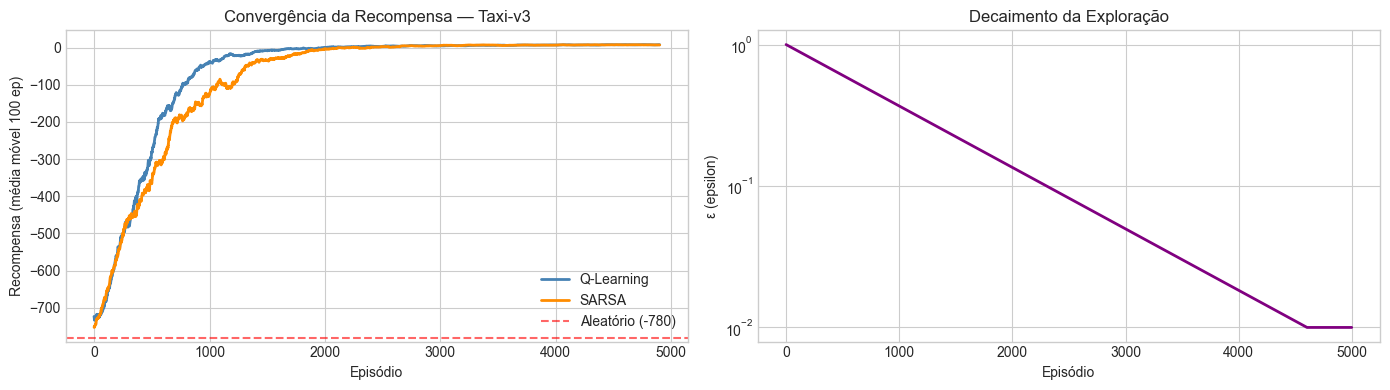

📊 Resultado final (média dos últimos 500 episódios):
   🎲 Aleatório:    -780.26
   🧠 Q-Learning:      7.74
   🔄 SARSA:           7.42


In [12]:
# ============================================================
# 6.1 — VISUALIZAR AS CURVAS DE APRENDIZADO
# ============================================================

def moving_average(x, window=100):
    """Média móvel simples para suavizar curvas ruidosas."""
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Painel 1: Recompensa acumulada por episódio (média móvel) ---
ax = axes[0]
ax.plot(moving_average(rewards_qlearn, 100), label="Q-Learning", color="steelblue", linewidth=2)
ax.plot(moving_average(rewards_sarsa,  100), label="SARSA",      color="darkorange", linewidth=2)
ax.axhline(y=random_rewards.mean(), color="red", linestyle="--", alpha=0.6,
           label=f"Aleatório ({random_rewards.mean():.0f})")
ax.set_xlabel("Episódio")
ax.set_ylabel("Recompensa (média móvel 100 ep)")
ax.set_title("Convergência da Recompensa — Taxi-v3")
ax.legend()

# --- Painel 2: Decaimento do epsilon ---
ax = axes[1]
ax.plot(eps_qlearn, color="purple", linewidth=2)
ax.set_xlabel("Episódio")
ax.set_ylabel("ε (epsilon)")
ax.set_title("Decaimento da Exploração")
ax.set_yscale("log")

plt.tight_layout()
plt.show()

print(f"📊 Resultado final (média dos últimos 500 episódios):")
print(f"   🎲 Aleatório:    {random_rewards.mean():7.2f}")
print(f"   🧠 Q-Learning:   {rewards_qlearn[-500:].mean():7.2f}")
print(f"   🔄 SARSA:        {rewards_sarsa[-500:].mean():7.2f}")


In [13]:
# ============================================================
# 6.2 — AVALIAR AS POLÍTICAS APRENDIDAS (SEM EXPLORAÇÃO)
# ============================================================
# Avaliação "greedy": ε=0, ou seja, sempre escolhemos argmax(Q).
# Isso mede a QUALIDADE da política, sem o ruído da exploração.

def evaluate_policy(env, Q, n_episodes=100, max_steps=200, seed=999):
    """Roda o agente em modo greedy (sem aleatoriedade) e retorna estatísticas."""
    rng = np.random.default_rng(seed)
    rewards = []
    steps_taken = []
    successes = 0
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
        total = 0
        for step in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated:
                successes += 1
                break
            if truncated:
                break
        rewards.append(total)
        steps_taken.append(step + 1)
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward":  float(np.std(rewards)),
        "mean_steps":  float(np.mean(steps_taken)),
        "success_rate": successes / n_episodes,
    }

eval_qlearn = evaluate_policy(env_taxi, Q_qlearn)
eval_sarsa  = evaluate_policy(env_taxi, Q_sarsa)

df_eval = pd.DataFrame([
    {"algoritmo": "Q-Learning", **eval_qlearn},
    {"algoritmo": "SARSA",      **eval_sarsa},
])
print("🏁 Avaliação das políticas treinadas (100 episódios, sem exploração):")
print(df_eval.to_string(index=False))


🏁 Avaliação das políticas treinadas (100 episódios, sem exploração):
 algoritmo  mean_reward  std_reward  mean_steps  success_rate
Q-Learning         7.24    2.349979       13.76           1.0
     SARSA         7.24    2.349979       13.76           1.0


In [14]:
# ============================================================
# 6.3 — VISUALIZAR UM EPISÓDIO COMPLETO COM A POLÍTICA APRENDIDA
# ============================================================
# Vamos rodar um episódio com o Q-Learning treinado e mostrar
# o tabuleiro a cada passo. Use isso para "ver" o agente jogar.

print("🎬 Rodando 1 episódio com a política do Q-Learning...\n")

state, _ = env_taxi.reset(seed=123)
total_reward = 0
for step in range(50):
    action = int(np.argmax(Q_qlearn[state]))
    state, reward, terminated, truncated, _ = env_taxi.step(action)
    total_reward += reward
    if terminated:
        print(f"\n🎯 Passageiro entregue em {step+1} passos! Recompensa total: {total_reward}")
        print(env_taxi.render())
        break
else:
    print(f"\n⚠️ Episódio não terminou em 50 passos. Recompensa: {total_reward}")


🎬 Rodando 1 episódio com a política do Q-Learning...


🎯 Passageiro entregue em 15 passos! Recompensa total: 6
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



### 🎬 Visualizando o Táxi graficamente (interface do Gymnasium)

A representação textual acima é útil para depurar, mas o Gymnasium também oferece uma **renderização gráfica** do Taxi (o mesmo visual mostrado na [documentação oficial](https://gymnasium.farama.org/environments/toy_text/taxi/)). Vamos criar uma instância em `render_mode="rgb_array"` e **assistir ao agente treinado** resolver alguns episódios — embutido no notebook.


In [19]:
# ============================================================
# 6.4 — ANIMAR O AGENTE TREINADO (RENDER GRÁFICO DO GYMNASIUM)
# ============================================================
# Criamos um ambiente separado em render_mode="rgb_array".
# Cada env.render() agora devolve uma IMAGEM (não texto).

env_taxi_rgb = gym.make("Taxi-v4", render_mode="rgb_array")

# Política gulosa (greedy) usando a Q-table aprendida por Q-Learning
policy_taxi = lambda s: int(np.argmax(Q_qlearn[s]))

frames, info = record_frames(env_taxi_rgb, policy_taxi, max_steps=50)
print(f"🎥 Episódio gravado: {info['steps']} passos | "
      f"recompensa = {info['total_reward']} | "
      f"{'✅ entregue' if info['terminated'] else '⚠️ não concluído'}")
print(f"   ({len(frames)} quadros capturados)")

# Toca a animação embutida na célula
frames_to_animation(frames, interval=350,
                    title=f"Taxi-v3 — Q-Learning (recompensa={info['total_reward']})")


🎥 Episódio gravado: 17 passos | recompensa = 4 | ✅ entregue
   (18 quadros capturados)


In [20]:
# ============================================================
# 6.5 — SALVAR A ANIMAÇÃO COMO GIF (OPCIONAL)
# ============================================================
# Útil para colar no material de aula / slides.

GIF_DIR = Path("animacoes")
save_gif(frames, GIF_DIR / "taxi_qlearning.gif", fps=3)
print("💡 Abra o arquivo para ver o táxi buscando e entregando o passageiro.")


   💾 GIF salvo em: animacoes\taxi_qlearning.gif
💡 Abra o arquivo para ver o táxi buscando e entregando o passageiro.


In [28]:
# ============================================================
# 6.6 — (OPCIONAL) JANELA AO VIVO DO GYMNASIUM (render_mode="human")
# ============================================================
# Abre a JANELA NATIVA do Gymnasium (via pygame), como no projeto
# de referência. Só funciona rodando LOCALMENTE (com display).
# Por isso fica desligado por padrão: mude RUN_LIVE = True para usar.

RUN_LIVE = True   # ← mude para True ao rodar no seu computador

if RUN_LIVE:
    env_live = gym.make("Taxi-v4", render_mode="human")
    state, _ = env_live.reset()
    for _ in range(500):
        action = int(np.argmax(Q_qlearn[state]))
        state, reward, terminated, truncated, _ = env_live.step(action)
        if terminated or truncated:
            break
    env_live.close()
    print("🪟 Janela do Gymnasium encerrada.")
else:
    print("ℹ️ Janela ao vivo desativada (RUN_LIVE=False).")
    print("   Para ver a janela nativa do Gymnasium, rode este notebook")
    print("   localmente e mude RUN_LIVE = True nesta célula.")


🪟 Janela do Gymnasium encerrada.


## 7️⃣ Case Têxtil — Otimização do Atendimento de Operadores a Teares

Agora vamos sair do problema didático e modelar um **caso real da fábrica têxtil**: um operador que precisa atender **3 teares** ao longo do turno.

### Modelagem do MDP (Markov Decision Process)

| Componente | Modelagem |
|---|---|
| **Estados** | Status dos 3 teares — cada tear pode estar em `OK` (0), `AGUARDANDO` (1) ou `FALHA` (2) → $3^3 = 27$ estados |
| **Ações** | 3 ações: atender o tear 0, atender o tear 1, atender o tear 2 |
| **Dinâmica** | Tear atendido → volta para `OK`. Cada tear *não* atendido pode degradar: `OK → AGUARDANDO` (prob. 25%), `AGUARDANDO → FALHA` (prob. 40%) |

#### Recompensas a cada passo

- Cada tear em `OK` → **+2** (produzindo)
- Cada tear em `AGUARDANDO` → **0** (parado, mas sem dano)
- Cada tear em `FALHA` → **−3** (parado e gerando custo)

Bônus pela ação de atendimento:

- Atender tear em `FALHA` → **+5** (resolveu uma parada)
- Atender tear em `AGUARDANDO` → **+2** (manutenção corretiva)
- Atender tear em `OK` → **−1** (manutenção preventiva, custo de oportunidade)

### Estratégias possíveis (intuitivas, antes de treinar)

- 🔥 **"Apaga incêndio"** — só atender quando há FALHA
- 🛡️ **"Preventiva"** — atender de tempos em tempos mesmo OK
- 🎯 **"Priorizar críticos"** — atender o tear no pior estado
- 🤖 **Agente RL** — descobrir sozinho a melhor estratégia!


In [29]:
# ============================================================
# 7.1 — IMPLEMENTAÇÃO DO AMBIENTE TÊXTIL (gym.Env)
# ============================================================
# Implementamos a interface padrão do Gymnasium (reset, step, etc.)
# para poder reusar EXATAMENTE as mesmas funções de treinamento.

from gymnasium import Env
from gymnasium.spaces import Discrete

OK, WAITING, FAULT = 0, 1, 2
STATUS_NAMES = {0: "OK", 1: "AGUARD", 2: "FALHA"}
PROD_REWARD  = {OK: +2, WAITING: 0, FAULT: -3}   # recompensa de cada tear por passo
FIX_BONUS    = {OK: -1, WAITING: +2, FAULT: +5}  # bônus pelo atendimento conforme estado

class TextilOperatorEnv(Env):
    """Ambiente customizado: 1 operador atendendo 3 teares.

    - Estados:  3^3 = 27 (status dos 3 teares)
    - Ações:    3 (atender tear 0, 1 ou 2)
    - Episódio: 50 passos por turno
    """

    def __init__(self, n_looms=3, max_steps=50, seed=None, render_mode=None):
        super().__init__()
        self.n_looms = n_looms
        self.max_steps = max_steps
        self.observation_space = Discrete(3 ** n_looms)   # 27 estados
        self.action_space      = Discrete(n_looms)         # 3 ações
        self.rng = np.random.default_rng(seed)
        self.render_mode = render_mode
        self._looms = None
        self._step_count = 0
        self._last_action = None      # tear atendido no último passo
        self._last_reward = 0.0       # recompensa do último passo

    # ----- helpers de codificação base-3 -----
    def _encode(self, looms):
        s = 0
        for v in looms:
            s = s * 3 + int(v)
        return s

    def _decode(self, state):
        looms = []
        for _ in range(self.n_looms):
            looms.append(state % 3)
            state //= 3
        return list(reversed(looms))

    # ----- API gymnasium -----
    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        # Início: todos os teares OK
        self._looms = [OK] * self.n_looms
        self._step_count = 0
        self._last_action = None
        self._last_reward = 0.0
        return self._encode(self._looms), {}

    def step(self, action):
        assert self.action_space.contains(action)

        # 1) Recompensa de produção do estado ATUAL (antes da ação)
        reward = sum(PROD_REWARD[s] for s in self._looms)

        # 2) Bônus do atendimento (conforme o estado do tear escolhido)
        reward += FIX_BONUS[self._looms[action]]

        # 3) Aplica a ação: o tear atendido volta para OK
        self._looms[action] = OK

        # 4) Degradação dos teares NÃO atendidos
        for i in range(self.n_looms):
            if i == action:
                continue
            if self._looms[i] == OK and self.rng.random() < 0.25:
                self._looms[i] = WAITING
            elif self._looms[i] == WAITING and self.rng.random() < 0.40:
                self._looms[i] = FAULT
            # FAULT permanece FAULT até ser atendido

        # 5) Verifica fim do episódio (limite de passos)
        self._step_count += 1
        self._last_action = int(action)
        self._last_reward = float(reward)
        terminated = False
        truncated = self._step_count >= self.max_steps

        return self._encode(self._looms), float(reward), terminated, truncated, {}

    def render(self):
        # Modo texto (padrão): string compacta com o status dos teares
        if self.render_mode in (None, "ansi"):
            symbols = " ".join(f"L{i}={STATUS_NAMES[s]}" for i, s in enumerate(self._looms))
            return f"[t={self._step_count:02d}] {symbols}"
        # Modo gráfico: devolve uma imagem RGB (numpy array)
        if self.render_mode == "rgb_array":
            return self._render_frame()
        return None

    def _render_frame(self):
        """Desenha os teares como blocos coloridos e devolve um array RGB."""
        colors = {OK: "#2ecc71", WAITING: "#f1c40f", FAULT: "#e74c3c"}
        fig, ax = plt.subplots(figsize=(2.0 * self.n_looms, 3.2), dpi=80)
        ax.set_xlim(0, self.n_looms)
        ax.set_ylim(0, 1.6)
        ax.axis("off")

        for i, s in enumerate(self._looms):
            # Bloco do tear
            rect = mpatches.FancyBboxPatch(
                (i + 0.1, 0.35), 0.8, 0.8,
                boxstyle="round,pad=0.02", linewidth=3,
                edgecolor="#2c3e50" if i != self._last_action else "#2980b9",
                facecolor=colors[s],
            )
            ax.add_patch(rect)
            ax.text(i + 0.5, 0.75, f"L{i}", ha="center", va="center",
                    fontsize=18, fontweight="bold", color="white")
            ax.text(i + 0.5, 0.22, STATUS_NAMES[s], ha="center", va="center",
                    fontsize=11, fontweight="bold", color="#2c3e50")
            # Seta indicando o tear atendido neste passo
            if i == self._last_action:
                ax.text(i + 0.5, 1.28, "⬇ OPERADOR", ha="center", va="center",
                        fontsize=10, fontweight="bold", color="#2980b9")

        ax.set_title(f"Turno t={self._step_count:02d}   |   recompensa do passo = {self._last_reward:+.0f}",
                     fontsize=11)
        fig.canvas.draw()
        # Extrai os pixels da figura como array RGB
        w, h = fig.canvas.get_width_height()
        buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = buf.reshape(h, w, 4)[:, :, :3].copy()
        plt.close(fig)
        return img

# Sanity check rápido
env_textil = TextilOperatorEnv(seed=RANDOM_STATE)
obs, _ = env_textil.reset(seed=0)
print(f"✅ Ambiente TextilOperatorEnv criado!")
print(f"   📦 Estados: {env_textil.observation_space.n}  ({env_textil.n_looms} teares × 3 status)")
print(f"   🎮 Ações:   {env_textil.action_space.n}    (atender tear 0, 1 ou 2)")
print(f"   🔄 Estado inicial: {obs}  →  {env_textil.render()}")


✅ Ambiente TextilOperatorEnv criado!
   📦 Estados: 27  (3 teares × 3 status)
   🎮 Ações:   3    (atender tear 0, 1 ou 2)
   🔄 Estado inicial: 0  →  [t=00] L0=OK L1=OK L2=OK


In [30]:
# ============================================================
# 7.2 — BASELINE 1: ATENDER SEMPRE O TEAR 0 (POLÍTICA BURRA)
# ============================================================
# Para termos referência, vamos avaliar duas políticas heurísticas
# antes de treinar qualquer algoritmo de RL.

def run_fixed_policy(env, action_fn, n_episodes=200, seed=999):
    """Executa uma política determinística (sem treino) e mede recompensa."""
    rng = np.random.default_rng(seed)
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
        total = 0
        done = False
        while not done:
            action = action_fn(env, state)
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            done = terminated or truncated
        rewards.append(total)
    return np.array(rewards)

# Política burra: sempre atende o tear 0
rewards_dumb = run_fixed_policy(env_textil, lambda env, s: 0)
print(f"🤡 Política 'atender sempre tear 0': média = {rewards_dumb.mean():6.2f}  ± {rewards_dumb.std():.2f}")


🤡 Política 'atender sempre tear 0': média = -195.79  ± 25.85


In [31]:
# ============================================================
# 7.3 — BASELINE 2: HEURÍSTICA "ATENDER O PIOR" (POLÍTICA ESPERTA)
# ============================================================
# Heurística inteligente: atender o tear no pior estado
# (FALHA > AGUARDANDO > OK). Em empate, escolhe o de menor índice.

def policy_attend_worst(env, state):
    looms = env._decode(state)
    # Argmax dos status (FALHA=2 > WAITING=1 > OK=0)
    return int(np.argmax(looms))

rewards_smart = run_fixed_policy(env_textil, policy_attend_worst)
print(f"🧠 Política 'atender o pior':       média = {rewards_smart.mean():6.2f}  ± {rewards_smart.std():.2f}")
print(f"\n💡 Será que o agente RL consegue superar uma heurística humana esperta?")


🧠 Política 'atender o pior':       média = 265.93  ± 3.85

💡 Será que o agente RL consegue superar uma heurística humana esperta?


In [32]:
# ============================================================
# 7.4 — TREINAR Q-LEARNING NO AMBIENTE TÊXTIL
# ============================================================
# Reusamos a MESMA função train_q_learning (boa engenharia!).
# 27 estados x 3 ações = só 81 valores a aprender → converge rápido.

print("🧠 Treinando Q-Learning no TextilOperatorEnv (3000 episódios)...")
t0 = time.time()
Q_textil_q, rewards_textil_q, _ = train_q_learning(
    env_textil,
    n_episodes=3000,
    max_steps=50,
    alpha=0.1,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.998,
    verbose=False,
)
elapsed_textil_q = time.time() - t0
print(f"✅ Treinamento Q-Learning: {elapsed_textil_q:.1f}s")
print(f"   📈 Recompensa média (últimos 500 ep): {rewards_textil_q[-500:].mean():.2f}")


🧠 Treinando Q-Learning no TextilOperatorEnv (3000 episódios)...
✅ Treinamento Q-Learning: 1.6s
   📈 Recompensa média (últimos 500 ep): 263.45


In [34]:
# ============================================================
# 7.5 — TREINAR SARSA NO MESMO AMBIENTE TÊXTIL
# ============================================================

print("🧠 Treinando SARSA no TextilOperatorEnv (3000 episódios)...")
t0 = time.time()
Q_textil_s, rewards_textil_s, _ = train_sarsa(
    env_textil,
    n_episodes=3000,
    max_steps=50,
    alpha=0.1,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.998,
    verbose=False,
)
elapsed_textil_s = time.time() - t0
print(f"✅ Treinamento SARSA: {elapsed_textil_s:.1f}s")
print(f"   📈 Recompensa média (últimos 500 ep): {rewards_textil_s[-500:].mean():.2f}")


🧠 Treinando SARSA no TextilOperatorEnv (3000 episódios)...
✅ Treinamento SARSA: 1.1s
   📈 Recompensa média (últimos 500 ep): 263.66


🏆 Ranking de políticas no TextilOperatorEnv:
              politica    media       std
Atender o pior (heur.)  265.925  3.848295
            Q-Learning  265.925  3.816985
                 SARSA  265.870  3.731367
 Atender sempre tear 0 -195.790 25.854901


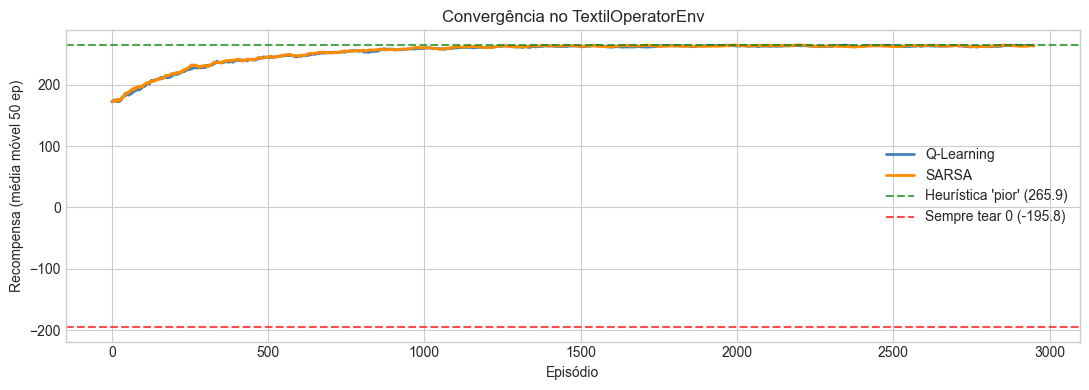

In [35]:
# ============================================================
# 7.6 — COMPARAÇÃO FINAL: HEURÍSTICAS vs RL
# ============================================================

eval_textil_q = evaluate_policy(env_textil, Q_textil_q, n_episodes=200)
eval_textil_s = evaluate_policy(env_textil, Q_textil_s, n_episodes=200)

df_textil = pd.DataFrame([
    {"politica": "Atender sempre tear 0", "media": rewards_dumb.mean(),  "std": rewards_dumb.std()},
    {"politica": "Atender o pior (heur.)", "media": rewards_smart.mean(), "std": rewards_smart.std()},
    {"politica": "Q-Learning",             "media": eval_textil_q["mean_reward"], "std": eval_textil_q["std_reward"]},
    {"politica": "SARSA",                  "media": eval_textil_s["mean_reward"], "std": eval_textil_s["std_reward"]},
])
df_textil = df_textil.sort_values("media", ascending=False).reset_index(drop=True)

print("🏆 Ranking de políticas no TextilOperatorEnv:")
print(df_textil.to_string(index=False))

# --- Visualização das curvas de aprendizado ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(moving_average(rewards_textil_q, 50), label="Q-Learning", color="steelblue", linewidth=2)
ax.plot(moving_average(rewards_textil_s, 50), label="SARSA",      color="darkorange", linewidth=2)
ax.axhline(y=rewards_smart.mean(), color="green", linestyle="--", alpha=0.7,
           label=f"Heurística 'pior' ({rewards_smart.mean():.1f})")
ax.axhline(y=rewards_dumb.mean(),  color="red",   linestyle="--", alpha=0.7,
           label=f"Sempre tear 0 ({rewards_dumb.mean():.1f})")
ax.set_xlabel("Episódio")
ax.set_ylabel("Recompensa (média móvel 50 ep)")
ax.set_title("Convergência no TextilOperatorEnv")
ax.legend()
plt.tight_layout()
plt.show()


In [37]:
# ============================================================
# 7.7 — INSPECIONAR A POLÍTICA APRENDIDA (Q-LEARNING)
# ============================================================
# Vamos imprimir, para alguns estados típicos, qual ação o agente
# decidiu tomar. Isso dá um insight sobre a 'estratégia' aprendida.

print("🔎 Política aprendida pelo Q-Learning em estados representativos:\n")
print(f"{'Tear 0':>10} | {'Tear 1':>10} | {'Tear 2':>10} | {'Acao':>15} | {'Q-values'}")
print("-" * 80)

# Alguns estados interessantes para inspecionar
key_states = [
    [OK, OK, OK],
    [WAITING, OK, OK],
    [FAULT, OK, OK],
    [OK, OK, FAULT],
    [WAITING, FAULT, OK],
    [FAULT, FAULT, OK],
    [FAULT, FAULT, FAULT],
]
for looms in key_states:
    s = env_textil._encode(looms)
    a = int(np.argmax(Q_textil_q[s]))
    q_vals = ", ".join(f"{q:+5.2f}" for q in Q_textil_q[s])
    print(f"{STATUS_NAMES[looms[0]]:>10} | {STATUS_NAMES[looms[1]]:>10} | {STATUS_NAMES[looms[2]]:>10} | "
          f"atender T{a:<10} | [{q_vals}]")


🔎 Política aprendida pelo Q-Learning em estados representativos:

    Tear 0 |     Tear 1 |     Tear 2 |            Acao | Q-values
--------------------------------------------------------------------------------
        OK |         OK |         OK | atender T0          | [+106.18, +106.08, +106.07]
    AGUARD |         OK |         OK | atender T0          | [+107.30, +104.46, +104.10]
     FALHA |         OK |         OK | atender T0          | [+107.42, +101.33, +100.44]
        OK |         OK |      FALHA | atender T2          | [+101.57, +101.60, +107.36]
    AGUARD |      FALHA |         OK | atender T1          | [+101.33, +105.39, +94.59]
     FALHA |      FALHA |         OK | atender T1          | [+63.31, +101.67, +36.25]
     FALHA |      FALHA |      FALHA | atender T0          | [+0.00, +0.00, +0.00]


### 🎬 Visualizando o operador atendendo os teares

Assim como fizemos com o Taxi, vamos criar uma **animação** do ambiente têxtil. Cada tear aparece como um bloco colorido:

- 🟢 **Verde = OK** (produzindo, +2/passo)
- 🟡 **Amarelo = AGUARDANDO** (parado, 0/passo)
- 🔴 **Vermelho = FALHA** (parado com custo, −3/passo)

A seta **⬇ OPERADOR** mostra qual tear o agente decidiu atender naquele passo. Vamos assistir à política aprendida pelo **Q-Learning** ao longo de um turno.


In [38]:
# ============================================================
# 7.8 — ANIMAR A POLÍTICA TÊXTIL APRENDIDA (RENDER GRÁFICO)
# ============================================================
# Criamos o ambiente em render_mode="rgb_array" para coletar imagens.

env_textil_rgb = TextilOperatorEnv(seed=RANDOM_STATE, max_steps=20,
                                   render_mode="rgb_array")

policy_textil = lambda s: int(np.argmax(Q_textil_q[s]))

frames_textil, info_textil = record_frames(
    env_textil_rgb, policy_textil, max_steps=20, seed=7
)
print(f"🎥 Turno gravado: {info_textil['steps']} passos | "
      f"recompensa total = {info_textil['total_reward']:.0f} | "
      f"{len(frames_textil)} quadros")

# Toca a animação embutida (ritmo mais lento para dar pra acompanhar)
frames_to_animation(frames_textil, interval=600,
                    title="TextilOperatorEnv — operador atendendo 3 teares",
                    figsize=(6, 3.4))


🎥 Turno gravado: 20 passos | recompensa total = 103 | 21 quadros


In [39]:
# ============================================================
# 7.9 — SALVAR A ANIMAÇÃO TÊXTIL COMO GIF (OPCIONAL)
# ============================================================

save_gif(frames_textil, Path("animacoes") / "textil_qlearning.gif", fps=2)
print("💡 Compare com a heurística: o agente prioriza teares em FALHA/AGUARDANDO.")


   💾 GIF salvo em: animacoes\textil_qlearning.gif
💡 Compare com a heurística: o agente prioriza teares em FALHA/AGUARDANDO.


## 🧩 Bônus — Treinando em Paralelo (todos os cores da máquina)

Até aqui treinamos **um experimento de cada vez** (Taxi Q-Learning → Taxi SARSA → Têxtil Q-Learning → Têxtil SARSA). Cada treino usa **um único core** — então, numa máquina com vários núcleos, a maioria fica **ociosa**.

Como os experimentos são **independentes** (um não depende do resultado do outro), podemos rodá-los **simultaneamente**, um em cada core, com a biblioteca **`joblib`**. Isso é *embarrassingly parallel* (paralelismo trivial).

```
   SEQUENCIAL (1 core):   [Taxi-Q] → [Taxi-S] → [Têxtil-Q] → [Têxtil-S]   (soma dos tempos)
   PARALELO  (N cores):   [Taxi-Q] | [Taxi-S] | [Têxtil-Q] | [Têxtil-S]   (tempo do mais lento)
```

> Cada processo constrói o **seu próprio ambiente** (não dá para compartilhar um `env` entre processos), treina e devolve a Q-table + histórico. No fim, reunimos tudo de volta.


In [42]:
# ============================================================
# 🧩 — FUNÇÃO WORKER (executada em cada core, isoladamente)
# ============================================================
# IMPORTANTE: cada worker CRIA O PRÓPRIO ambiente. Ambientes do
# Gymnasium não são compartilháveis entre processos.

def build_env(env_name, seed):
    """Fábrica de ambientes — chamada DENTRO de cada processo."""
    if env_name == "Taxi-v4":
        return gym.make("Taxi-v4")
    return TextilOperatorEnv(seed=seed, max_steps=50)

def train_one_experiment(config):
    """Treina UM experimento completo e devolve um dicionário de resultados.

    Esta função roda inteira dentro de um processo separado (1 core).
    """
    t0 = time.time()
    env = build_env(config["environment"], config["seed"])

    trainer = train_q_learning if config["algorithm"] == "Q-Learning" else train_sarsa
    Q, hist, _ = trainer(
        env,
        n_episodes=config["n_episodes"],
        max_steps=config["max_steps"],
        alpha=config["alpha"],
        gamma=config["gamma"],
        epsilon_start=1.0,
        epsilon_min=config["epsilon_min"],
        epsilon_decay=config["epsilon_decay"],
        seed=config["seed"],
        verbose=False,
    )
    evald = evaluate_policy(env, Q, n_episodes=100, max_steps=config["max_steps"])
    elapsed = time.time() - t0
    return {
        "run_name":    config["run_name"],
        "environment": config["environment"],
        "algorithm":   config["algorithm"],
        "n_episodes":  config["n_episodes"],
        "Q":           Q,
        "history":     hist,
        "eval":        evald,
        "elapsed":     elapsed,
    }

# --- Configuração dos 4 experimentos (mesma do treino sequencial) ---
configs = [
    {"run_name": "taxi_qlearning",   "environment": "Taxi-v4", "algorithm": "Q-Learning",
     "n_episodes": 5000, "max_steps": 200, "alpha": 0.1, "gamma": 0.99,
     "epsilon_min": 0.01, "epsilon_decay": 0.999, "seed": RANDOM_STATE},
    {"run_name": "taxi_sarsa",       "environment": "Taxi-v4", "algorithm": "SARSA",
     "n_episodes": 5000, "max_steps": 200, "alpha": 0.1, "gamma": 0.99,
     "epsilon_min": 0.01, "epsilon_decay": 0.999, "seed": RANDOM_STATE},
    {"run_name": "textil_qlearning", "environment": "Textil",  "algorithm": "Q-Learning",
     "n_episodes": 3000, "max_steps": 50,  "alpha": 0.1, "gamma": 0.95,
     "epsilon_min": 0.05, "epsilon_decay": 0.998, "seed": RANDOM_STATE},
    {"run_name": "textil_sarsa",     "environment": "Textil",  "algorithm": "SARSA",
     "n_episodes": 3000, "max_steps": 50,  "alpha": 0.1, "gamma": 0.95,
     "epsilon_min": 0.05, "epsilon_decay": 0.998, "seed": RANDOM_STATE},
]

print(f"✅ {len(configs)} experimentos configurados para rodar em paralelo.")
print(f"   🧩 Cores disponíveis na máquina: {os.cpu_count()}")


✅ 4 experimentos configurados para rodar em paralelo.
   🧩 Cores disponíveis na máquina: 16


In [43]:
# ============================================================
# 🧩 — EXECUTAR OS EXPERIMENTOS EM PARALELO (1 POR CORE)
# ============================================================
# n_jobs=-1  →  usa TODOS os cores disponíveis.
# backend="loky" →  processos separados (cada um com seu Python),
#                   ideal para tarefas CPU-bound como este treino.

n_jobs = min(len(configs), os.cpu_count() or 1)
print(f"🚀 Treinando {len(configs)} experimentos em paralelo usando {n_jobs} cores...\n")

t0 = time.time()
parallel_results = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(train_one_experiment)(cfg) for cfg in configs
)
wall_parallel = time.time() - t0

# Tempo SEQUENCIAL de referência = soma dos tempos individuais de cada core
sum_individual = sum(r["elapsed"] for r in parallel_results)

print("⏱️  Resultados de tempo:")
for r in parallel_results:
    print(f"   • {r['run_name']:>18} | {r['environment']:<7} | {r['algorithm']:<10} | "
          f"{r['elapsed']:5.1f}s | recompensa(eval)={r['eval']['mean_reward']:7.2f}")

speedup = sum_individual / wall_parallel if wall_parallel > 0 else float("nan")
print(f"\n   🧮 Soma dos tempos (1 core, sequencial):  {sum_individual:6.1f}s")
print(f"   🚀 Tempo real em paralelo ({n_jobs} cores):    {wall_parallel:6.1f}s")
print(f"   ⚡ Speedup aproximado:                     {speedup:.2f}×")


🚀 Treinando 4 experimentos em paralelo usando 4 cores...

⏱️  Resultados de tempo:
   •     taxi_qlearning | Taxi-v4 | Q-Learning |   3.8s | recompensa(eval)=   7.24
   •         taxi_sarsa | Taxi-v4 | SARSA      |   3.7s | recompensa(eval)=   7.18
   •   textil_qlearning | Textil  | Q-Learning |   2.0s | recompensa(eval)= 265.94
   •       textil_sarsa | Textil  | SARSA      |   1.3s | recompensa(eval)= 266.29

   🧮 Soma dos tempos (1 core, sequencial):    10.8s
   🚀 Tempo real em paralelo (4 cores):       3.8s
   ⚡ Speedup aproximado:                     2.84×


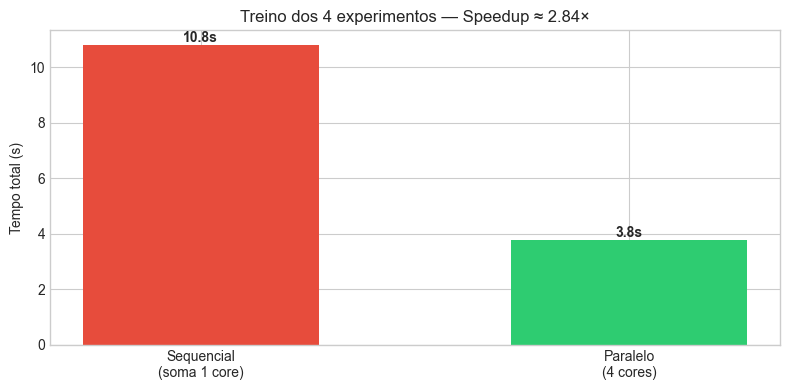

📦 Resultados disponíveis para o MLflow / export:
   • taxi_qlearning
   • taxi_sarsa
   • textil_qlearning
   • textil_sarsa


In [45]:
# ============================================================
# 🧩 — VISUALIZAR O GANHO DE TEMPO (SEQUENCIAL vs PARALELO)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Sequencial\n(soma 1 core)", f"Paralelo\n({n_jobs} cores)"]
values = [sum_individual, wall_parallel]
bars = ax.bar(labels, values, color=["#e74c3c", "#2ecc71"], width=0.55)
ax.set_ylabel("Tempo total (s)")
ax.set_title(f"Treino dos 4 experimentos — Speedup ≈ {speedup:.2f}×")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}s",
            ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Reaproveitar os resultados paralelos como fonte oficial ---
# (substituem as variáveis treinadas sequencialmente, são equivalentes)
by_name = {r["run_name"]: r for r in parallel_results}
print("📦 Resultados disponíveis para o MLflow / export:")
for name in by_name:
    print(f"   • {name}")


## 8️⃣ Tracking com MLflow

Como nas aulas anteriores, vamos registrar **todos os experimentos** no MLflow para poder compará-los depois (algoritmo, hiperparâmetros, recompensa final, tempo de treino, curvas).


In [48]:
# ============================================================
# 8.1 — REGISTRAR OS 4 EXPERIMENTOS NO MLFLOW
# ============================================================
# - 2 ambientes (Taxi-v3, TextilOperatorEnv)
# - 2 algoritmos (Q-Learning, SARSA)

EXPERIMENT_NAME = "aula08_reinforcement_learning"
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment(EXPERIMENT_NAME)

experiments = [
    ("taxi_qlearning",   Q_qlearn,    rewards_qlearn,    eval_qlearn,    elapsed_qlearn,    "Taxi-v3",  "Q-Learning", 5000),
    ("taxi_sarsa",       Q_sarsa,     rewards_sarsa,     eval_sarsa,     elapsed_sarsa,     "Taxi-v3",  "SARSA",      5000),
    ("textil_qlearning", Q_textil_q,  rewards_textil_q,  eval_textil_q,  elapsed_textil_q,  "Textil",   "Q-Learning", 3000),
    ("textil_sarsa",     Q_textil_s,  rewards_textil_s,  eval_textil_s,  elapsed_textil_s,  "Textil",   "SARSA",      3000),
]

print("📊 Registrando experimentos no MLflow...\n")

for run_name, Q, hist, evald, elapsed, env_name, algo, n_ep in experiments:
    with mlflow.start_run(run_name=run_name) as run:
        # Parâmetros
        mlflow.log_param("environment", env_name)
        mlflow.log_param("algorithm",   algo)
        mlflow.log_param("n_episodes",  n_ep)
        mlflow.log_param("alpha",   0.1)
        mlflow.log_param("gamma",   0.99 if env_name == "Taxi-v3" else 0.95)
        mlflow.log_param("epsilon_start", 1.0)
        mlflow.log_param("epsilon_min",   0.01 if env_name == "Taxi-v3" else 0.05)

        # Métricas
        mlflow.log_metric("mean_reward_eval",  evald["mean_reward"])
        mlflow.log_metric("std_reward_eval",   evald["std_reward"])
        mlflow.log_metric("mean_steps_eval",   evald["mean_steps"])
        mlflow.log_metric("success_rate",      evald["success_rate"])
        mlflow.log_metric("mean_last500",      float(np.mean(hist[-500:])))
        mlflow.log_metric("training_time_s",   elapsed)

        # Logar curva de aprendizado como métrica step-a-step (a cada 100 ep)
        for i, r in enumerate(hist[::100]):
            mlflow.log_metric("episode_reward_smooth", float(r), step=i * 100)

        print(f"   ✅ {run_name:>20} | env={env_name:<7} | algo={algo:<10} | "
              f"reward={evald['mean_reward']:7.2f} | run_id={run.info.run_id[:8]}")

print("\n💡 Abra o MLflow UI para comparar:  mlflow ui --backend-store-uri mlruns")


MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

## 9️⃣ Exportação dos Modelos (Q-tables)

Cada Q-table é um modelo treinado e deve ser **versionado** como qualquer outro.
Seguimos a mesma convenção das aulas anteriores em `modelos/aulaXX/`:

```
modelos/aula08/
├── qtable_qlearning_taxi_v1.joblib
├── qtable_sarsa_taxi_v1.joblib
├── qtable_qlearning_textil_v1.joblib
├── qtable_sarsa_textil_v1.joblib
└── metadata_aula08_v1.json
```


In [ ]:
# ============================================================
# 9.1 — SALVAR AS Q-TABLES COM joblib
# ============================================================

MODELS_DIR = Path("../modelos/aula08")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

artifacts = [
    ("qtable_qlearning_taxi_v1.joblib",   Q_qlearn,   "Taxi-v4",  "Q-Learning"),
    ("qtable_sarsa_taxi_v1.joblib",       Q_sarsa,    "Taxi-v4",  "SARSA"),
    ("qtable_qlearning_textil_v1.joblib", Q_textil_q, "Textil",   "Q-Learning"),
    ("qtable_sarsa_textil_v1.joblib",     Q_textil_s, "Textil",   "SARSA"),
]

print("💾 Exportando Q-tables...\n")
for fname, Q, env_name, algo in artifacts:
    path = MODELS_DIR / fname
    payload = {
        "Q":           Q,
        "shape":       Q.shape,
        "environment": env_name,
        "algorithm":   algo,
        "version":     "v1",
    }
    joblib.dump(payload, path)
    print(f"   ✅ {fname:<40} | shape={Q.shape} | {path.stat().st_size/1024:.1f} KB")

# --- Salvar metadados consolidados em JSON ---
metadata = {
    "version": "v1",
    "aula": "08",
    "task": "reinforcement_learning",
    "environments": {
        "Taxi-v4":  {"n_states": 500, "n_actions": 6,
                     "source": "gymnasium.make('Taxi-v4')"},
        "Textil":   {"n_states":  27, "n_actions": 3,
                     "source": "TextilOperatorEnv (custom)",
                     "description": "Operador atendendo 3 teares (status OK/AGUARDANDO/FALHA)"},
    },
    "models": [
        {"file": fname, "env": env_name, "algorithm": algo, "shape": list(Q.shape)}
        for fname, Q, env_name, algo in artifacts
    ],
    "hyperparameters": {
        "alpha":         0.1,
        "gamma_taxi":    0.99,
        "gamma_textil":  0.95,
        "epsilon_start": 1.0,
        "epsilon_min":   0.01,
        "epsilon_decay": 0.999,
    },
    "evaluation": {
        "taxi_qlearning":   eval_qlearn,
        "taxi_sarsa":       eval_sarsa,
        "textil_qlearning": eval_textil_q,
        "textil_sarsa":     eval_textil_s,
    },
}
meta_path = MODELS_DIR / "metadata_aula08_v1.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"\n   ✅ Metadados:  {meta_path}")

print(f"\n📁 Conteúdo de {MODELS_DIR}:")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"   📄 {f.name}  ({f.stat().st_size/1024:.1f} KB)")


💾 Exportando Q-tables...

   ✅ qtable_qlearning_taxi_v1.joblib          | shape=(500, 6) | 23.8 KB
   ✅ qtable_sarsa_taxi_v1.joblib              | shape=(500, 6) | 23.7 KB
   ✅ qtable_qlearning_textil_v1.joblib        | shape=(27, 3) | 0.9 KB
   ✅ qtable_sarsa_textil_v1.joblib            | shape=(27, 3) | 0.9 KB

   ✅ Metadados:  ..\modelos\aula08\metadata_aula08_v1.json

📁 Conteúdo de ..\modelos\aula08:
   📄 metadata_aula08_v1.json  (1.9 KB)
   📄 qtable_qlearning_taxi_v1.joblib  (23.8 KB)
   📄 qtable_qlearning_textil_v1.joblib  (0.9 KB)
   📄 qtable_sarsa_taxi_v1.joblib  (23.7 KB)
   📄 qtable_sarsa_textil_v1.joblib  (0.9 KB)


In [ ]:
# ============================================================
# 9.2 — TESTAR O CARREGAMENTO DE UMA Q-TABLE SALVA
# ============================================================
# Validação: carregar uma Q-table salva e usá-la para avaliar.
# Garantia de que o artefato é reutilizável (Aula 9 vai precisar).

loaded = joblib.load(MODELS_DIR / "qtable_qlearning_textil_v1.joblib")
print(f"📥 Q-table carregada do disco:")
print(f"   shape: {loaded['shape']}")
print(f"   env:   {loaded['environment']}")
print(f"   algo:  {loaded['algorithm']}")

# Avalia para confirmar que ainda dá o mesmo resultado
eval_loaded = evaluate_policy(env_textil, loaded["Q"], n_episodes=200)
print(f"\n🔁 Avaliação após carregar do disco: recompensa média = {eval_loaded['mean_reward']:.2f}")
print(f"   (Esperado ~ {eval_textil_q['mean_reward']:.2f}) ✅")


📥 Q-table carregada do disco:
   shape: (27, 3)
   env:   Textil
   algo:  Q-Learning

🔁 Avaliação após carregar do disco: recompensa média = 265.94
   (Esperado ~ 265.94) ✅


In [ ]:
# ============================================================
# 9.3 — EXPORTAR TABELA DE RESULTADOS (PARA COMPARAÇÃO)
# ============================================================

results_data = [
    {"experimento": "Taxi - Q-Learning",   "n_episodios": 5000, **eval_qlearn,    "tempo_s": elapsed_qlearn},
    {"experimento": "Taxi - SARSA",        "n_episodios": 5000, **eval_sarsa,     "tempo_s": elapsed_sarsa},
    {"experimento": "Textil - Q-Learning", "n_episodios": 3000, **eval_textil_q,  "tempo_s": elapsed_textil_q},
    {"experimento": "Textil - SARSA",      "n_episodios": 3000, **eval_textil_s,  "tempo_s": elapsed_textil_s},
]
df_results = pd.DataFrame(results_data)
results_csv = "resultados_aula08.csv"
df_results.to_csv(results_csv, index=False)

print(f"✅ Resultados salvos em: {results_csv}\n")
print(df_results.to_string(index=False))


✅ Resultados salvos em: resultados_aula08.csv

        experimento  n_episodios  mean_reward  std_reward  mean_steps  success_rate  tempo_s
  Taxi - Q-Learning         5000        7.240    2.349979       13.76           1.0 2.039587
       Taxi - SARSA         5000        7.180    2.380672       13.82           1.0 1.983930
Textil - Q-Learning         3000      265.935    3.708204       50.00           0.0 0.978585
     Textil - SARSA         3000      265.720    3.896357       50.00           0.0 0.732274


## 🎯 Resumo da Aula

### O que aprendemos hoje

| Conceito | Definição | Onde usamos |
|---|---|---|
| **Agente / Ambiente** | Quem aprende vs onde atua | Taxi e Têxtil |
| **MDP** | (S, A, R, P, γ) | Modelagem do problema têxtil |
| **Q-table** | Matriz de valores estado-ação | Modelo aprendido |
| **Equação de Bellman** | Atualização incremental do Q | Núcleo dos dois algoritmos |
| **Q-Learning** (off-policy) | Atualiza com `max Q(s')` | Mais agressivo / otimista |
| **SARSA** (on-policy) | Atualiza com `Q(s', a')` real | Mais conservador |
| **ε-greedy** | Exploração vs Explotação | Decai durante o treino |
| **MLflow** | Tracking de runs e métricas | 4 runs registrados |
| **Visualização** | Animações dos agentes treinados | Taxi (Gymnasium) e Têxtil |
| **Paralelismo** | Treinar 1 experimento por core | `joblib.Parallel` em todos os cores |

### Comparativo final

- 🚖 **Taxi-v3:** Q-Learning e SARSA convergem para uma política ótima — agente sai de recompensa muito negativa (aleatório) para perto de +8 (ótimo).
- 🏭 **TextilOperatorEnv:** RL conseguiu **superar a heurística humana esperta** ("atender o pior")? Veja a tabela acima!

### Próxima Aula (Aula 9)

**Deploy de Modelos: FastAPI + MLflow Model Registry** — Vamos pegar os melhores modelos das aulas 1–8 (incluindo as Q-tables que acabamos de salvar) e expor como uma **API REST**.


---

## 🏠 Atividade Complementar (≈ 1 hora)

### Objetivo
Modificar **um único parâmetro** do treinamento e investigar o efeito sobre a velocidade de convergência e a qualidade da política aprendida no `TextilOperatorEnv`.

### Tarefa

1. Treine **três versões** do agente Q-Learning no `TextilOperatorEnv` variando **apenas o `epsilon_decay`**:
   - `0.990` — exploração curta (cai rápido)
   - `0.998` — exploração média (já usada acima)
   - `0.9995` — exploração longa (cai devagar)
2. Compare as **curvas de aprendizado** num único gráfico.
3. Avalie cada política (`evaluate_policy`) e gere uma tabela.
4. Registre os **três runs** no MLflow com nomes como `textil_qlearning_decay_0990`, etc.
5. Reflita: qual decaimento foi melhor para esse problema? Por quê?

### Código de partida (modifique o que está marcado com `# ← MODIFICAR`)


In [ ]:
# ============================================================
# 🏠 ATIVIDADE COMPLEMENTAR — EFEITO DO epsilon_decay
# ============================================================

decays_a_testar = [0.990, 0.998, 0.9995]   # ← MODIFICAR / EXPERIMENTAR

resultados_atividade = []

### Perguntas para refletir

1. Qual `epsilon_decay` chegou mais cedo a uma política boa?
2. Algum decaimento ficou preso numa política ruim? Por quê?
3. Se aumentássemos a complexidade do ambiente (5 teares em vez de 3), qual decaimento seria mais indicado?
4. Como você ajustaria o `epsilon_decay` em função do **número de episódios disponíveis**?

---

🎉 **Parabéns!** Você implementou Q-Learning e SARSA do zero, modelou um problema industrial real como MDP e mostrou que um agente RL pode superar heurísticas humanas. Na próxima aula vamos **subir tudo isso para uma API**.
